In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ml_library import KMeansClustering , z_score_normalization , train_test_split , pca

In [2]:
df = pd.read_csv("./dataset/unsupervised_data.csv")
df.shape

(40000, 7)

In [3]:
df.head()

,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6
0,1,-21.904591,-22.659091,12.805995,-46.631935,-34.347081,-21.989738
1,2,-28.662385,68.757081,31.761821,3.982259,-62.876866,-61.838563
2,3,-62.551204,60.909235,8.112918,24.110050,-64.372336,70.681940
3,4,14.428024,-48.326045,-65.576518,76.027549,69.966852,48.023953
4,5,9.780285,-55.643172,-72.737299,74.180123,67.873327,41.128015


In [4]:
df[df.isnull().any(axis=1)]

,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         40000 non-null  int64  
 1   Feature_1  40000 non-null  float64
 2   Feature_2  40000 non-null  float64
 3   Feature_3  40000 non-null  float64
 4   Feature_4  40000 non-null  float64
 5   Feature_5  40000 non-null  float64
 6   Feature_6  40000 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 2.1 MB


In [6]:
X = df.drop('ID', axis=1).values

#k = 5

In [7]:
X = z_score_normalization(X)

In [8]:
X_pca = pca(X, 2)

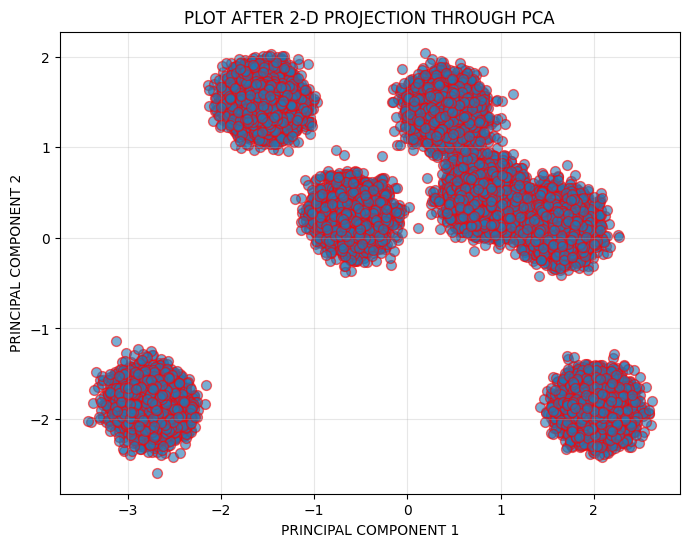

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=50, alpha=0.6, edgecolor="red")
plt.title("PLOT AFTER 2-D PROJECTION THROUGH PCA")
plt.xlabel("PRINCIPAL COMPONENT 1")
plt.ylabel("PRINCIPAL COMPONENT 2")
plt.grid(alpha=0.3)
plt.show()

In [10]:
model = KMeansClustering(k=5, max_iters=100)

model.fit(X)

In [11]:
y_pred = model.predict(X)

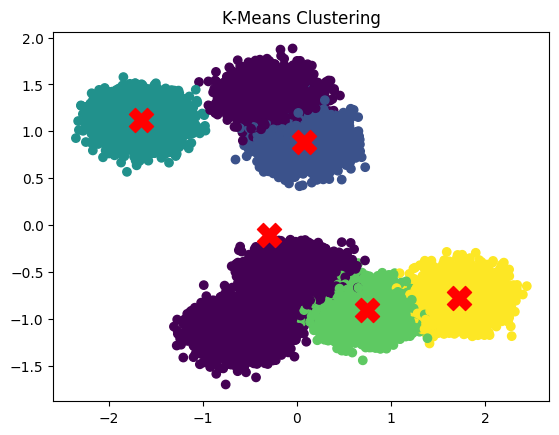

In [12]:
model.plot_clusters(X)

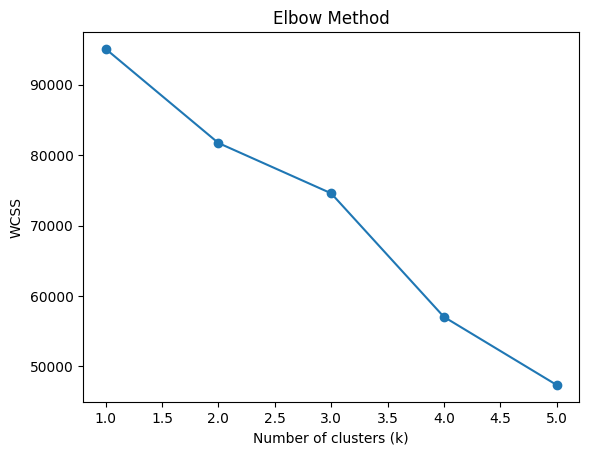

In [15]:
model.plot_elbow_method(X, max_k=5)